In [1]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs detectadas:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.20.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import pandas as pd

CAMINHO_CSV = "/kaggle/input/notebooks/monicalanjos071829/01-verificacao-dataset-pneumonia/base_modelagem_divisao_80_10_10.csv"

base_modelagem = pd.read_csv(CAMINHO_CSV)

print("Dimensão do CSV:", base_modelagem.shape)

Dimensão do CSV: (5824, 11)


In [3]:
print(base_modelagem["divisao_nova"].value_counts())

divisao_nova
treino       4682
teste         581
validacao     561
Name: count, dtype: int64


In [4]:
tabela_classes = pd.crosstab(
    base_modelagem["divisao_nova"],
    base_modelagem["classe"]
)

print(tabela_classes)

classe        NORMAL  PNEUMONIA
divisao_nova                   
teste            166        415
treino          1259       3423
validacao        154        407


In [5]:
mapa_classes = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

base_modelagem["rotulo"] = base_modelagem["classe"].map(mapa_classes)

print(base_modelagem[["classe", "rotulo"]].drop_duplicates())

         classe  rotulo
0        NORMAL       0
1340  PNEUMONIA       1


In [6]:
print("Rótulos ausentes:", base_modelagem["rotulo"].isna().sum())
print("Valores encontrados:", sorted(base_modelagem["rotulo"].dropna().unique()))

Rótulos ausentes: 0
Valores encontrados: [np.int64(0), np.int64(1)]


In [7]:
base_treino = base_modelagem[
    base_modelagem["divisao_nova"] == "treino"
].copy()

base_validacao = base_modelagem[
    base_modelagem["divisao_nova"] == "validacao"
].copy()

base_teste = base_modelagem[
    base_modelagem["divisao_nova"] == "teste"
].copy()

print("Treino:", len(base_treino))
print("Validação:", len(base_validacao))
print("Teste:", len(base_teste))

Treino: 4682
Validação: 561
Teste: 581


In [8]:
caminhos_treino = base_treino["caminho"].to_numpy()
rotulos_treino = base_treino["rotulo"].to_numpy()

caminhos_validacao = base_validacao["caminho"].to_numpy()
rotulos_validacao = base_validacao["rotulo"].to_numpy()

caminhos_teste = base_teste["caminho"].to_numpy()
rotulos_teste = base_teste["rotulo"].to_numpy()

print("Treino:")
print("Caminhos:", len(caminhos_treino))
print("Rótulos:", len(rotulos_treino))

print("\nValidação:")
print("Caminhos:", len(caminhos_validacao))
print("Rótulos:", len(rotulos_validacao))

print("\nTeste:")
print("Caminhos:", len(caminhos_teste))
print("Rótulos:", len(rotulos_teste))

Treino:
Caminhos: 4682
Rótulos: 4682

Validação:
Caminhos: 561
Rótulos: 561

Teste:
Caminhos: 581
Rótulos: 581


In [9]:
import os

arquivos_ausentes = [
    caminho
    for caminho in base_modelagem["caminho"]
    if not os.path.exists(caminho)
]

print("Arquivos ausentes:", len(arquivos_ausentes))

Arquivos ausentes: 0


In [10]:
ALTURA_IMG = 224
LARGURA_IMG = 224
BATCH_SIZE = 32

def carregar_imagem_cnn(caminho):
    imagem = tf.io.read_file(caminho)
    imagem = tf.io.decode_jpeg(imagem, channels=3)
    imagem = tf.image.resize(
        imagem,
        [ALTURA_IMG, LARGURA_IMG]
    )
    imagem = tf.cast(imagem, tf.float32)
    imagem = imagem / 255.0

    return imagem

In [11]:
imagem_teste = carregar_imagem_cnn(caminhos_treino[0])

print("Formato:", imagem_teste.shape)
print("Tipo:", imagem_teste.dtype)
print("Pixel mínimo:", float(tf.reduce_min(imagem_teste)))
print("Pixel máximo:", float(tf.reduce_max(imagem_teste)))

Formato: (224, 224, 3)
Tipo: <dtype: 'float32'>
Pixel mínimo: 0.0
Pixel máximo: 1.0


I0000 00:00:1787013285.392137      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
def preparar_exemplo_cnn(caminho, rotulo):
    imagem = carregar_imagem_cnn(caminho)
    rotulo = tf.cast(rotulo, tf.float32)

    return imagem, rotulo

In [13]:
imagem_exemplo, rotulo_exemplo = preparar_exemplo_cnn(
    caminhos_treino[0],
    rotulos_treino[0]
)

print("Formato da imagem:", imagem_exemplo.shape)
print("Tipo da imagem:", imagem_exemplo.dtype)
print("Rótulo:", rotulo_exemplo.numpy())
print("Tipo do rótulo:", rotulo_exemplo.dtype)

Formato da imagem: (224, 224, 3)
Tipo da imagem: <dtype: 'float32'>
Rótulo: 0.0
Tipo do rótulo: <dtype: 'float32'>


In [14]:
dataset_treino = tf.data.Dataset.from_tensor_slices(
    (caminhos_treino, rotulos_treino)
)

dataset_validacao = tf.data.Dataset.from_tensor_slices(
    (caminhos_validacao, rotulos_validacao)
)

dataset_teste = tf.data.Dataset.from_tensor_slices(
    (caminhos_teste, rotulos_teste)
)

dataset_treino = dataset_treino.map(
    preparar_exemplo_cnn,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_validacao = dataset_validacao.map(
    preparar_exemplo_cnn,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_teste = dataset_teste.map(
    preparar_exemplo_cnn,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [15]:
print("Treino:", dataset_treino.element_spec)
print("Validação:", dataset_validacao.element_spec)
print("Teste:", dataset_teste.element_spec)

Treino: (TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))
Validação: (TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))
Teste: (TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))


In [16]:
SEED = 42

dataset_treino = dataset_treino.shuffle(
    buffer_size=len(caminhos_treino),
    seed=SEED,
    reshuffle_each_iteration=True
)

In [17]:
print(dataset_treino.element_spec)

(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))


In [18]:
dataset_treino = dataset_treino.batch(BATCH_SIZE)

dataset_validacao = dataset_validacao.batch(BATCH_SIZE)

dataset_teste = dataset_teste.batch(BATCH_SIZE)

In [19]:
print("Treino:", dataset_treino.element_spec)
print("Validação:", dataset_validacao.element_spec)
print("Teste:", dataset_teste.element_spec)

Treino: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Validação: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Teste: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [20]:
imagens_batch, rotulos_batch = next(iter(dataset_treino))

print("Formato das imagens:", imagens_batch.shape)
print("Formato dos rótulos:", rotulos_batch.shape)

print("Tipo das imagens:", imagens_batch.dtype)
print("Tipo dos rótulos:", rotulos_batch.dtype)

print("Pixel mínimo:", float(tf.reduce_min(imagens_batch)))
print("Pixel máximo:", float(tf.reduce_max(imagens_batch)))

print("Primeiros 10 rótulos:", rotulos_batch[:10].numpy())

Formato das imagens: (32, 224, 224, 3)
Formato dos rótulos: (32,)
Tipo das imagens: <dtype: 'float32'>
Tipo dos rótulos: <dtype: 'float32'>
Pixel mínimo: 0.0
Pixel máximo: 1.0
Primeiros 10 rótulos: [1. 0. 1. 0. 1. 1. 1. 1. 0. 1.]


In [21]:
dataset_treino = dataset_treino.prefetch(tf.data.AUTOTUNE)

dataset_validacao = dataset_validacao.prefetch(tf.data.AUTOTUNE)

dataset_teste = dataset_teste.prefetch(tf.data.AUTOTUNE)

In [22]:
print("Treino:", dataset_treino.element_spec)
print("Validação:", dataset_validacao.element_spec)
print("Teste:", dataset_teste.element_spec)

Treino: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Validação: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Teste: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))


In [23]:
tf.keras.utils.set_random_seed(SEED)

In [24]:
modelo_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(ALTURA_IMG, LARGURA_IMG, 3)
    ),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        filters=256,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        units=1,
        activation="sigmoid"
    )
])

In [25]:
modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        )
    ]
)

In [27]:
print("Optimizer:", type(modelo_cnn.optimizer).__name__)
print(
    "Learning rate:",
    float(modelo_cnn.optimizer.learning_rate.numpy())
)
print("Loss:", type(modelo_cnn.loss).__name__)

Optimizer: Adam
Learning rate: 0.0010000000474974513
Loss: BinaryCrossentropy


In [28]:
EPOCHS = 30

print("Máximo de épocas:", EPOCHS)

Máximo de épocas: 30


In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

In [30]:
CAMINHO_MELHOR_MODELO = "/kaggle/working/cnn_baseline_best.keras"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=CAMINHO_MELHOR_MODELO,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [31]:
callbacks_cnn = [
    early_stopping,
    model_checkpoint
]

print("Callbacks configurados:", len(callbacks_cnn))

Callbacks configurados: 2


In [32]:
print("EarlyStopping:")
print("Monitor:", early_stopping.monitor)
print("Patience:", early_stopping.patience)
print("Restore best weights:", early_stopping.restore_best_weights)

print("\nModelCheckpoint:")
print("Monitor:", model_checkpoint.monitor)
print("Salvar apenas melhor:", model_checkpoint.save_best_only)
print("Caminho:", model_checkpoint.filepath)

EarlyStopping:
Monitor: val_loss
Patience: 5
Restore best weights: True

ModelCheckpoint:
Monitor: val_loss
Salvar apenas melhor: True
Caminho: /kaggle/working/cnn_baseline_best.keras


In [33]:
historico_cnn = modelo_cnn.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1
)

Epoch 1/30
  5/147 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6701 - loss: 0.6477 - precision: 0.7751 - recall: 0.7556 - roc_auc: 0.5879

I0000 00:00:1787013340.698243      67 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7387 - loss: 0.5680 - precision: 0.7507 - recall: 0.9650 - roc_auc: 0.6076
Epoch 1: val_loss improved from None to 0.40665, saving model to /kaggle/working/cnn_baseline_best.keras

Epoch 1: finished saving model to /kaggle/working/cnn_baseline_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.7715 - loss: 0.4800 - precision: 0.7881 - recall: 0.9401 - roc_auc: 0.7730 - val_accuracy: 0.7629 - val_loss: 0.4067 - val_precision: 0.8914 - val_recall: 0.7666 - val_roc_auc: 0.8556
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8307 - loss: 0.3740 - precision: 0.9110 - recall: 0.8453 - roc_auc: 0.8866
Epoch 2: val_loss improved from 0.40665 to 0.37735, saving model to /kaggle/working/cnn_baseline_best.keras

Epoch 2: finished saving model to /kaggle/working/cnn_baseline_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8405 - loss: 0.3477 - precision: 0.9130 - recall: 0.8642 - roc_au

In [34]:
import numpy as np

historico = historico_cnn.history

numero_epocas = len(historico["loss"])
melhor_indice = np.argmin(historico["val_loss"])
melhor_epoca = melhor_indice + 1

print("Épocas executadas:", numero_epocas)
print("Melhor época:", melhor_epoca)
print("Melhor val_loss:", historico["val_loss"][melhor_indice])

Épocas executadas: 21
Melhor época: 16
Melhor val_loss: 0.15469224750995636


In [35]:
print("MÉTRICAS DA MELHOR ÉPOCA")

print("\nTreino:")
print("Loss:", historico["loss"][melhor_indice])
print("Accuracy:", historico["accuracy"][melhor_indice])
print("Precision:", historico["precision"][melhor_indice])
print("Recall:", historico["recall"][melhor_indice])
print("ROC-AUC:", historico["roc_auc"][melhor_indice])

print("\nValidação:")
print("Loss:", historico["val_loss"][melhor_indice])
print("Accuracy:", historico["val_accuracy"][melhor_indice])
print("Precision:", historico["val_precision"][melhor_indice])
print("Recall:", historico["val_recall"][melhor_indice])
print("ROC-AUC:", historico["val_roc_auc"][melhor_indice])

MÉTRICAS DA MELHOR ÉPOCA

Treino:
Loss: 0.11314563453197479
Accuracy: 0.9570696353912354
Precision: 0.9721571207046509
Recall: 0.9690330028533936
ROC-AUC: 0.9893348217010498

Validação:
Loss: 0.15469224750995636
Accuracy: 0.9340463280677795
Precision: 0.9490291476249695
Recall: 0.9606879353523254
ROC-AUC: 0.9834232330322266


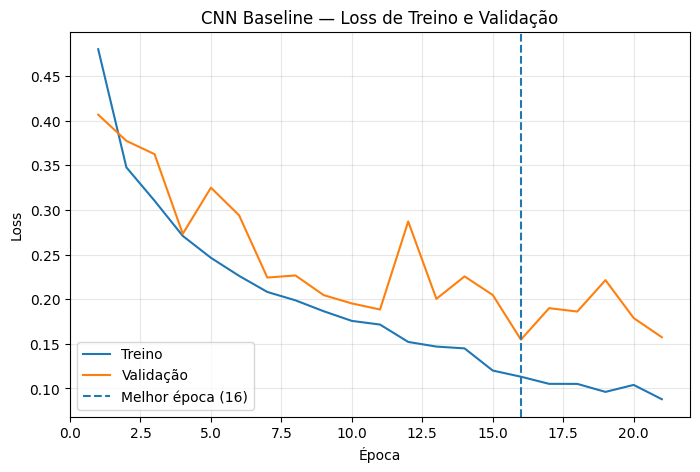

In [36]:
import matplotlib.pyplot as plt

epocas = range(1, len(historico["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    historico["loss"],
    label="Treino"
)

plt.plot(
    epocas,
    historico["val_loss"],
    label="Validação"
)

plt.axvline(
    x=melhor_epoca,
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("CNN Baseline — Loss de Treino e Validação")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

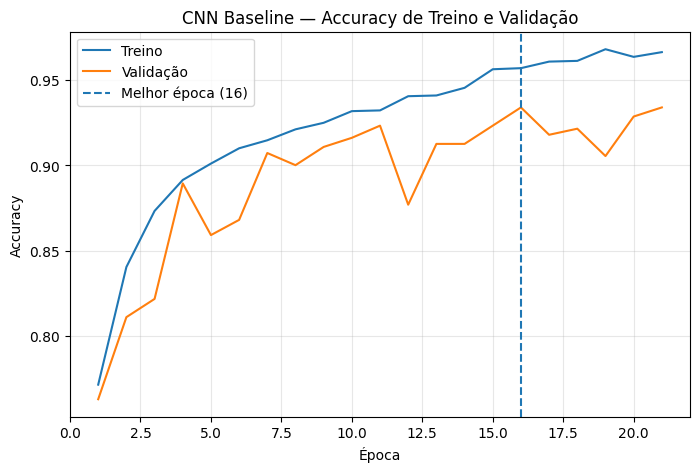

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    historico["accuracy"],
    label="Treino"
)

plt.plot(
    epocas,
    historico["val_accuracy"],
    label="Validação"
)

plt.axvline(
    x=melhor_epoca,
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("CNN Baseline — Accuracy de Treino e Validação")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

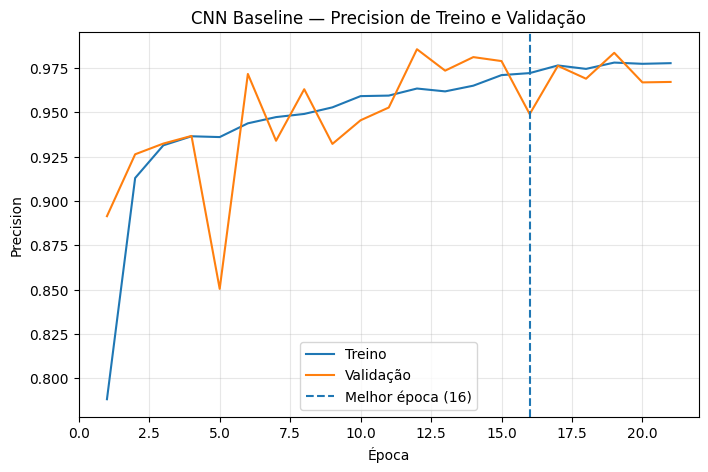

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    historico["precision"],
    label="Treino"
)

plt.plot(
    epocas,
    historico["val_precision"],
    label="Validação"
)

plt.axvline(
    x=melhor_epoca,
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})"
)

plt.xlabel("Época")
plt.ylabel("Precision")
plt.title("CNN Baseline — Precision de Treino e Validação")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

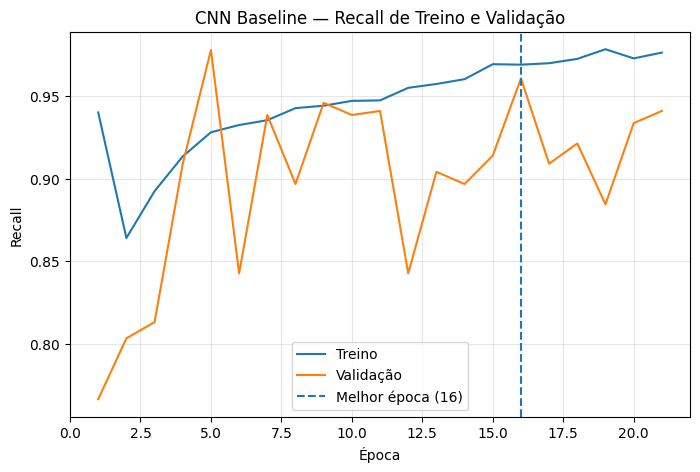

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    historico["recall"],
    label="Treino"
)

plt.plot(
    epocas,
    historico["val_recall"],
    label="Validação"
)

plt.axvline(
    x=melhor_epoca,
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})"
)

plt.xlabel("Época")
plt.ylabel("Recall")
plt.title("CNN Baseline — Recall de Treino e Validação")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

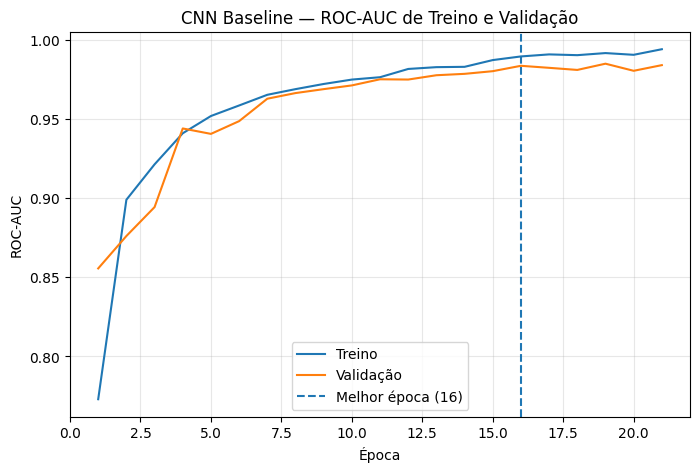

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    historico["roc_auc"],
    label="Treino"
)

plt.plot(
    epocas,
    historico["val_roc_auc"],
    label="Validação"
)

plt.axvline(
    x=melhor_epoca,
    linestyle="--",
    label=f"Melhor época ({melhor_epoca})"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.title("CNN Baseline — ROC-AUC de Treino e Validação")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [41]:
import os

print(
    "Checkpoint existe:",
    os.path.exists(CAMINHO_MELHOR_MODELO)
)

print(
    "Caminho:",
    CAMINHO_MELHOR_MODELO
)

Checkpoint existe: True
Caminho: /kaggle/working/cnn_baseline_best.keras


In [42]:
melhor_modelo_cnn = tf.keras.models.load_model(
    CAMINHO_MELHOR_MODELO
)

In [43]:
print("Modelo carregado com sucesso.")

print(
    "Total de parâmetros:",
    melhor_modelo_cnn.count_params()
)

print(
    "Optimizer:",
    type(melhor_modelo_cnn.optimizer).__name__
)

print(
    "Loss:",
    type(melhor_modelo_cnn.loss).__name__
)

Modelo carregado com sucesso.
Total de parâmetros: 421441
Optimizer: Adam
Loss: BinaryCrossentropy


In [44]:
resultados_teste = melhor_modelo_cnn.evaluate(
    dataset_teste,
    return_dict=True,
    verbose=1
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.9466 - loss: 0.1273 - precision: 0.9528 - recall: 0.9735 - roc_auc: 0.9892


In [45]:
print("RESULTADOS AGREGADOS — TESTE")

for metrica, valor in resultados_teste.items():
    print(f"{metrica}: {valor:.4f}")

RESULTADOS AGREGADOS — TESTE
accuracy: 0.9466
loss: 0.1273
precision: 0.9528
recall: 0.9735
roc_auc: 0.9892


In [46]:
probabilidades_teste = melhor_modelo_cnn.predict(
    dataset_teste,
    verbose=1
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step


In [47]:
print("Formato:", probabilidades_teste.shape)
print("Mínimo:", probabilidades_teste.min())
print("Máximo:", probabilidades_teste.max())
print("Primeiras 10 probabilidades:")
print(probabilidades_teste[:10])

Formato: (581, 1)
Mínimo: 0.0009134663
Máximo: 1.0
Primeiras 10 probabilidades:
[[0.06242164]
 [0.00283817]
 [0.01097569]
 [0.02377866]
 [0.01537854]
 [0.45054626]
 [0.42557707]
 [0.28411037]
 [0.43171954]
 [0.19754776]]


In [48]:
probabilidades_teste_1d = probabilidades_teste.ravel()

THRESHOLD = 0.5

predicoes_teste = (
    probabilidades_teste_1d >= THRESHOLD
).astype(int)

print("Formato das probabilidades:", probabilidades_teste_1d.shape)
print("Formato das previsões:", predicoes_teste.shape)
print("Classes previstas:", np.unique(predicoes_teste))

Formato das probabilidades: (581,)
Formato das previsões: (581,)
Classes previstas: [0 1]


In [49]:
valores, contagens = np.unique(
    predicoes_teste,
    return_counts=True
)

print("Distribuição das previsões:")

for valor, contagem in zip(valores, contagens):
    classe = "NORMAL" if valor == 0 else "PNEUMONIA"
    print(f"{classe}: {contagem}")

Distribuição das previsões:
NORMAL: 157
PNEUMONIA: 424


In [50]:
from sklearn.metrics import confusion_matrix

matriz_confusao = confusion_matrix(
    rotulos_teste,
    predicoes_teste,
    labels=[0, 1]
)

print("Matriz de Confusão:")
print(matriz_confusao)

Matriz de Confusão:
[[146  20]
 [ 11 404]]


In [51]:
tn, fp, fn, tp = matriz_confusao.ravel()

print("Verdadeiros Negativos (TN):", tn)
print("Falsos Positivos (FP):", fp)
print("Falsos Negativos (FN):", fn)
print("Verdadeiros Positivos (TP):", tp)

print("Total:", tn + fp + fn + tp)

Verdadeiros Negativos (TN): 146
Falsos Positivos (FP): 20
Falsos Negativos (FN): 11
Verdadeiros Positivos (TP): 404
Total: 581


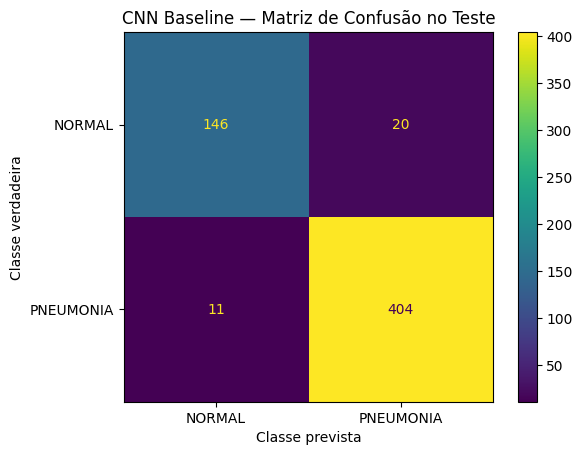

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["NORMAL", "PNEUMONIA"]
)

display_matriz.plot(
    values_format="d"
)

plt.title("CNN Baseline — Matriz de Confusão no Teste")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

In [53]:
from sklearn.metrics import f1_score

f1_teste = f1_score(
    rotulos_teste,
    predicoes_teste,
    pos_label=1
)

print("F1-score — PNEUMONIA:", f"{f1_teste:.4f}")

F1-score — PNEUMONIA: 0.9631


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metricas_cnn_teste = {
    "Accuracy": accuracy_score(
        rotulos_teste,
        predicoes_teste
    ),
    "Precision": precision_score(
        rotulos_teste,
        predicoes_teste,
        pos_label=1
    ),
    "Recall": recall_score(
        rotulos_teste,
        predicoes_teste,
        pos_label=1
    ),
    "F1-score": f1_score(
        rotulos_teste,
        predicoes_teste,
        pos_label=1
    ),
    "ROC-AUC": roc_auc_score(
        rotulos_teste,
        probabilidades_teste_1d
    )
}

In [55]:
tabela_metricas_cnn = pd.DataFrame(
    metricas_cnn_teste.items(),
    columns=["Métrica", "Valor"]
)

tabela_metricas_cnn["Valor (%)"] = (
    tabela_metricas_cnn["Valor"] * 100
)

print(tabela_metricas_cnn)

     Métrica     Valor  Valor (%)
0   Accuracy  0.946644  94.664372
1  Precision  0.952830  95.283019
2     Recall  0.973494  97.349398
3   F1-score  0.963051  96.305125
4    ROC-AUC  0.989186  98.918566


In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    rotulos_teste,
    probabilidades_teste_1d,
    pos_label=1
)

auc_teste = roc_auc_score(
    rotulos_teste,
    probabilidades_teste_1d
)

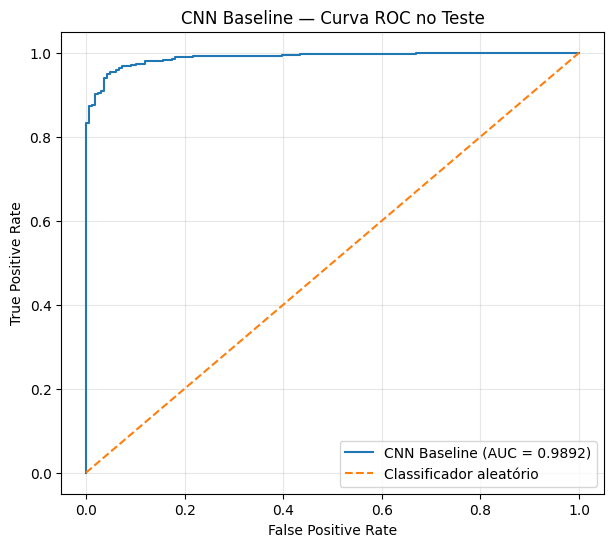

In [57]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CNN Baseline (AUC = {auc_teste:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN Baseline — Curva ROC no Teste")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [58]:
analise_teste = base_teste.copy()

analise_teste["probabilidade_pneumonia"] = probabilidades_teste_1d
analise_teste["rotulo_previsto"] = predicoes_teste

analise_teste["classe_prevista"] = analise_teste[
    "rotulo_previsto"
].map({
    0: "NORMAL",
    1: "PNEUMONIA"
})

analise_teste["erro"] = (
    analise_teste["rotulo"] != analise_teste["rotulo_previsto"]
)

In [59]:
print("Total de imagens:", len(analise_teste))
print("Acertos:", (~analise_teste["erro"]).sum())
print("Erros:", analise_teste["erro"].sum())

Total de imagens: 581
Acertos: 550
Erros: 31


In [60]:
falsos_positivos = analise_teste[
    (analise_teste["rotulo"] == 0) &
    (analise_teste["rotulo_previsto"] == 1)
].copy()

falsos_negativos = analise_teste[
    (analise_teste["rotulo"] == 1) &
    (analise_teste["rotulo_previsto"] == 0)
].copy()

print("Falsos positivos:", len(falsos_positivos))
print("Falsos negativos:", len(falsos_negativos))
print("Total de erros:", len(falsos_positivos) + len(falsos_negativos))

Falsos positivos: 20
Falsos negativos: 11
Total de erros: 31


In [61]:
print("FALSOS POSITIVOS")
print(
    falsos_positivos["probabilidade_pneumonia"]
    .describe()
)

print("\nFALSOS NEGATIVOS")
print(
    falsos_negativos["probabilidade_pneumonia"]
    .describe()
)

FALSOS POSITIVOS
count    20.000000
mean      0.751319
std       0.157715
min       0.511651
25%       0.633549
50%       0.735107
75%       0.922941
max       0.984743
Name: probabilidade_pneumonia, dtype: float64

FALSOS NEGATIVOS
count    11.000000
mean      0.317295
std       0.181899
min       0.020320
25%       0.178499
50%       0.380137
75%       0.465872
max       0.497836
Name: probabilidade_pneumonia, dtype: float64


In [62]:
erros_teste = analise_teste[
    analise_teste["erro"]
].copy()

erros_teste["distancia_threshold"] = (
    erros_teste["probabilidade_pneumonia"] - THRESHOLD
).abs()

erros_ordenados = erros_teste.sort_values(
    "distancia_threshold",
    ascending=False
)

colunas_erros = [
    "nome_arquivo",
    "classe",
    "classe_prevista",
    "probabilidade_pneumonia",
    "distancia_threshold"
]

print(
    erros_ordenados[colunas_erros]
    .head(10)
    .to_string(index=False)
)

                nome_arquivo    classe classe_prevista  probabilidade_pneumonia  distancia_threshold
   NORMAL2-IM-0259-0001.jpeg    NORMAL       PNEUMONIA                 0.984743             0.484743
    person277_virus_571.jpeg PNEUMONIA          NORMAL                 0.020320             0.479680
   NORMAL2-IM-0222-0001.jpeg    NORMAL       PNEUMONIA                 0.968486             0.468486
   NORMAL2-IM-0229-0001.jpeg    NORMAL       PNEUMONIA                 0.967477             0.467477
person559_bacteria_2329.jpeg PNEUMONIA          NORMAL                 0.065294             0.434706
   NORMAL2-IM-0201-0001.jpeg    NORMAL       PNEUMONIA                 0.929620             0.429620
           IM-0017-0001.jpeg    NORMAL       PNEUMONIA                 0.928358             0.428358
   NORMAL2-IM-0282-0001.jpeg    NORMAL       PNEUMONIA                 0.921136             0.421136
   person703_virus_1300.jpeg PNEUMONIA          NORMAL                 0.079205            

In [63]:
fp_extremos = falsos_positivos.sort_values(
    "probabilidade_pneumonia",
    ascending=False
).head(3)

fn_extremos = falsos_negativos.sort_values(
    "probabilidade_pneumonia",
    ascending=True
).head(3)

erros_extremos_visualizacao = pd.concat(
    [fp_extremos, fn_extremos],
    ignore_index=True
)

print(
    erros_extremos_visualizacao[
        [
            "nome_arquivo",
            "classe",
            "classe_prevista",
            "probabilidade_pneumonia"
        ]
    ].to_string(index=False)
)

                nome_arquivo    classe classe_prevista  probabilidade_pneumonia
   NORMAL2-IM-0259-0001.jpeg    NORMAL       PNEUMONIA                 0.984743
   NORMAL2-IM-0222-0001.jpeg    NORMAL       PNEUMONIA                 0.968486
   NORMAL2-IM-0229-0001.jpeg    NORMAL       PNEUMONIA                 0.967477
    person277_virus_571.jpeg PNEUMONIA          NORMAL                 0.020320
person559_bacteria_2329.jpeg PNEUMONIA          NORMAL                 0.065294
   person703_virus_1300.jpeg PNEUMONIA          NORMAL                 0.079205


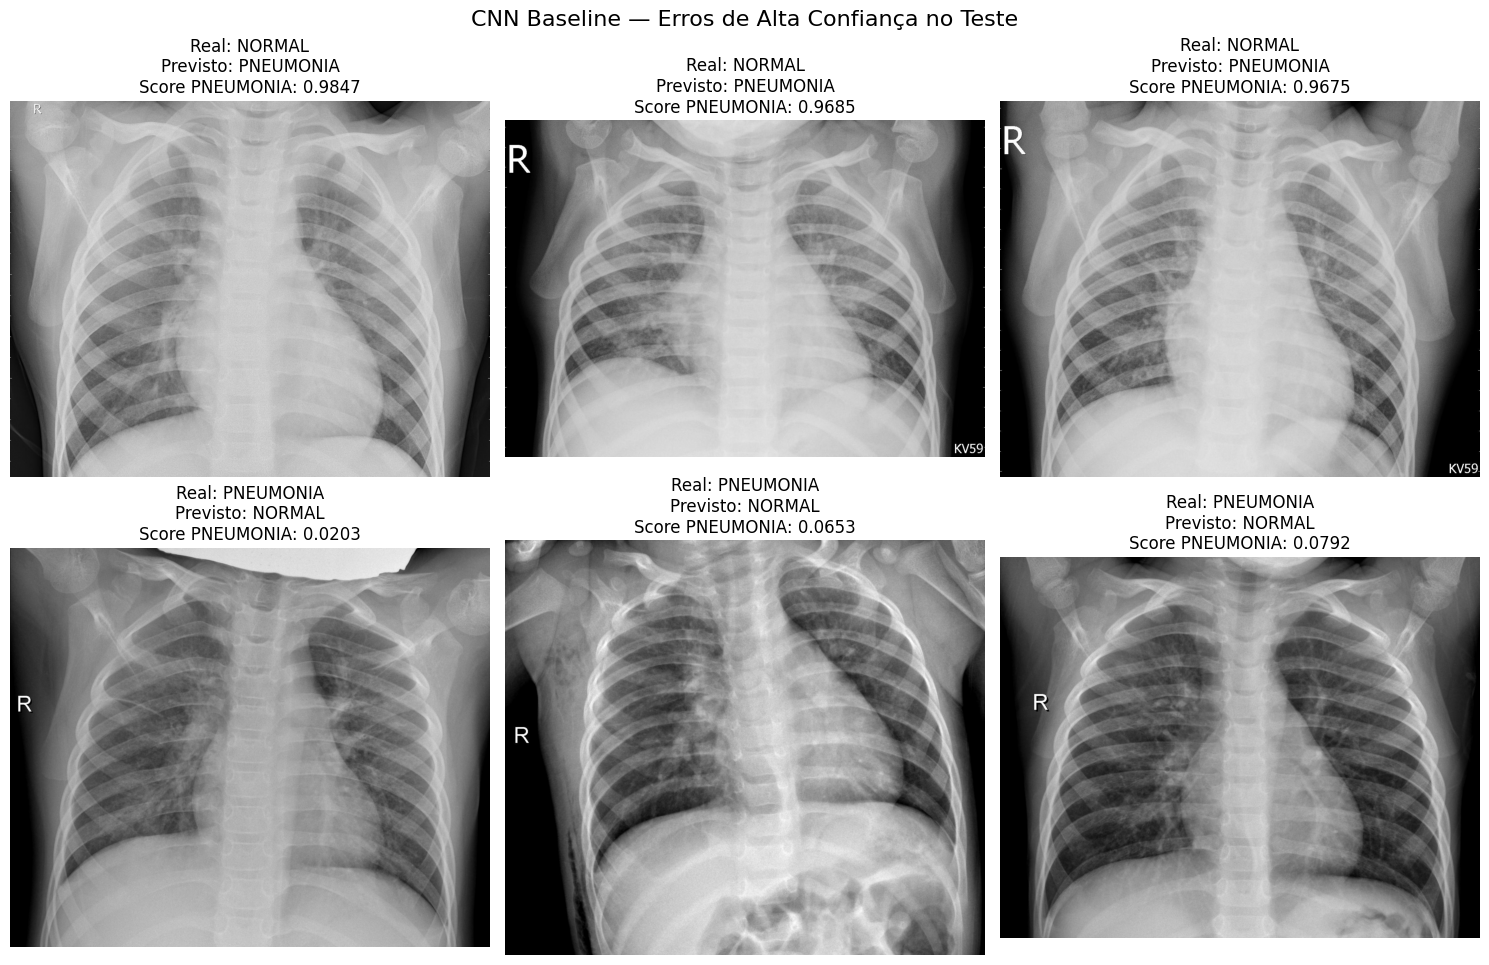

In [64]:
from PIL import Image

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

for ax, (_, linha) in zip(
    axes.ravel(),
    erros_extremos_visualizacao.iterrows()
):
    with Image.open(linha["caminho"]) as imagem:
        imagem_array = np.array(imagem)

    if imagem_array.ndim == 2:
        ax.imshow(imagem_array, cmap="gray")
    else:
        ax.imshow(imagem_array)

    ax.set_title(
        f"Real: {linha['classe']}\n"
        f"Previsto: {linha['classe_prevista']}\n"
        f"Score PNEUMONIA: {linha['probabilidade_pneumonia']:.4f}"
    )

    ax.axis("off")

plt.suptitle(
    "CNN Baseline — Erros de Alta Confiança no Teste",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [65]:
def obter_dimensoes_imagem(caminho):
    with Image.open(caminho) as imagem:
        largura, altura = imagem.size

    return largura, altura

In [66]:
dimensoes_teste = analise_teste["caminho"].apply(
    obter_dimensoes_imagem
)

analise_teste["largura"] = dimensoes_teste.apply(
    lambda x: x[0]
)

analise_teste["altura"] = dimensoes_teste.apply(
    lambda x: x[1]
)

analise_teste["razao_aspecto"] = (
    analise_teste["largura"] /
    analise_teste["altura"]
)

analise_teste["pixels_totais"] = (
    analise_teste["largura"] *
    analise_teste["altura"]
)

In [67]:
print("Imagens caracterizadas:", len(analise_teste))

print(
    analise_teste[
        [
            "largura",
            "altura",
            "razao_aspecto",
            "pixels_totais"
        ]
    ].isna().sum()
)

Imagens caracterizadas: 581
largura          0
altura           0
razao_aspecto    0
pixels_totais    0
dtype: int64


In [68]:
analise_teste["resultado_classificacao"] = np.where(
    analise_teste["erro"],
    "ERRO",
    "ACERTO"
)

print(
    analise_teste["resultado_classificacao"].value_counts()
)

resultado_classificacao
ACERTO    550
ERRO       31
Name: count, dtype: int64


In [69]:
comparacao_erros = (
    analise_teste
    .groupby("resultado_classificacao")[
        [
            "largura",
            "altura",
            "razao_aspecto",
            "pixels_totais"
        ]
    ]
    .median()
)

print(comparacao_erros)

                         largura  altura  razao_aspecto  pixels_totais
resultado_classificacao                                               
ACERTO                    1268.0   884.0       1.406046      1144576.0
ERRO                      1678.0  1259.0       1.273973      2347576.0


In [70]:
comparacao_erros_por_classe = (
    analise_teste
    .groupby(
        ["classe", "resultado_classificacao"]
    )[
        [
            "largura",
            "altura",
            "razao_aspecto",
            "pixels_totais"
        ]
    ]
    .median()
)

print(comparacao_erros_por_classe)

                                   largura  altura  razao_aspecto  \
classe    resultado_classificacao                                   
NORMAL    ACERTO                    1708.0  1375.5       1.215521   
          ERRO                      1801.5  1296.5       1.291767   
PNEUMONIA ACERTO                    1152.0   776.0       1.505573   
          ERRO                      1530.0  1229.0       1.258731   

                                   pixels_totais  
classe    resultado_classificacao                 
NORMAL    ACERTO                       2265822.0  
          ERRO                         2429511.5  
PNEUMONIA ACERTO                        893460.0  
          ERRO                         1747638.0  


<Figure size 900x600 with 0 Axes>

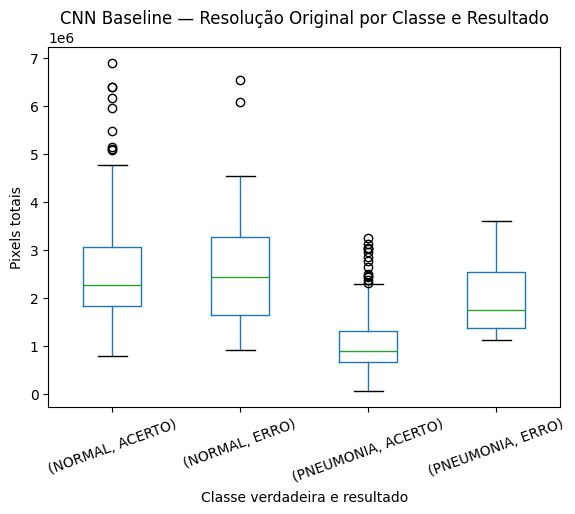

In [71]:
plt.figure(figsize=(9, 6))

analise_teste.boxplot(
    column="pixels_totais",
    by=["classe", "resultado_classificacao"],
    grid=False
)

plt.title(
    "CNN Baseline — Resolução Original por Classe e Resultado"
)
plt.suptitle("")

plt.xlabel("Classe verdadeira e resultado")
plt.ylabel("Pixels totais")

plt.xticks(rotation=20)

plt.show()

<Figure size 900x600 with 0 Axes>

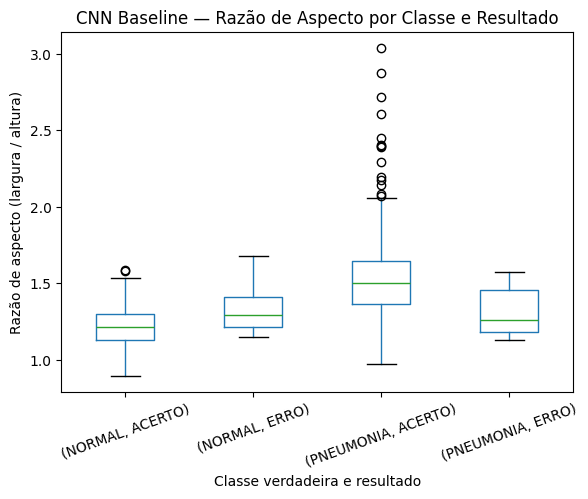

In [72]:
plt.figure(figsize=(9, 6))

analise_teste.boxplot(
    column="razao_aspecto",
    by=["classe", "resultado_classificacao"],
    grid=False
)

plt.title(
    "CNN Baseline — Razão de Aspecto por Classe e Resultado"
)
plt.suptitle("")

plt.xlabel("Classe verdadeira e resultado")
plt.ylabel("Razão de aspecto (largura / altura)")

plt.xticks(rotation=20)

plt.show()

In [73]:
CAMINHO_ANALISE_TESTE = (
    "/kaggle/working/analise_teste_cnn_baseline.csv"
)

analise_teste.to_csv(
    CAMINHO_ANALISE_TESTE,
    index=False
)

print("Arquivo salvo em:")
print(CAMINHO_ANALISE_TESTE)

print("Dimensão:", analise_teste.shape)

Arquivo salvo em:
/kaggle/working/analise_teste_cnn_baseline.csv
Dimensão: (581, 21)


In [74]:
analise_teste_reaberta = pd.read_csv(
    CAMINHO_ANALISE_TESTE
)

print("Dimensão após reabrir:", analise_teste_reaberta.shape)

print(
    "Erros após reabrir:",
    analise_teste_reaberta["erro"].sum()
)

print(
    "Coluna de probabilidade presente:",
    "probabilidade_pneumonia"
    in analise_teste_reaberta.columns
)

Dimensão após reabrir: (581, 21)
Erros após reabrir: 31
Coluna de probabilidade presente: True


In [75]:
historico_cnn_df = pd.DataFrame(
    historico_cnn.history
)

historico_cnn_df.insert(
    0,
    "epoca",
    range(1, len(historico_cnn_df) + 1)
)

CAMINHO_HISTORICO_CNN = (
    "/kaggle/working/historico_treinamento_cnn_baseline.csv"
)

historico_cnn_df.to_csv(
    CAMINHO_HISTORICO_CNN,
    index=False
)

print("Arquivo salvo em:")
print(CAMINHO_HISTORICO_CNN)

print("Dimensão:", historico_cnn_df.shape)

Arquivo salvo em:
/kaggle/working/historico_treinamento_cnn_baseline.csv
Dimensão: (21, 11)


In [76]:
historico_cnn_reaberto = pd.read_csv(
    CAMINHO_HISTORICO_CNN
)

print(
    "Dimensão após reabrir:",
    historico_cnn_reaberto.shape
)

indice_melhor_reaberto = (
    historico_cnn_reaberto["val_loss"].idxmin()
)

epoca_melhor_reaberta = historico_cnn_reaberto.loc[
    indice_melhor_reaberto,
    "epoca"
]

val_loss_melhor_reaberta = historico_cnn_reaberto.loc[
    indice_melhor_reaberto,
    "val_loss"
]

print(
    "Melhor época após reabrir:",
    int(epoca_melhor_reaberta)
)

print(
    "Melhor val_loss após reabrir:",
    val_loss_melhor_reaberta
)

Dimensão após reabrir: (21, 11)
Melhor época após reabrir: 16
Melhor val_loss após reabrir: 0.1546922475099563


In [77]:
resumo_cnn_baseline = pd.DataFrame({
    "item": [
        "modelo",
        "altura_entrada",
        "largura_entrada",
        "canais",
        "batch_size",
        "seed",
        "parametros_treinaveis",
        "optimizer",
        "learning_rate",
        "loss",
        "epocas_maximas",
        "epocas_executadas",
        "melhor_epoca",
        "melhor_val_loss",
        "accuracy_teste",
        "precision_teste",
        "recall_teste",
        "f1_teste",
        "roc_auc_teste",
        "tn",
        "fp",
        "fn",
        "tp"
    ],
    "valor": [
        "CNN baseline",
        ALTURA_IMG,
        LARGURA_IMG,
        3,
        BATCH_SIZE,
        SEED,
        melhor_modelo_cnn.count_params(),
        "Adam",
        0.001,
        "BinaryCrossentropy",
        EPOCHS,
        len(historico_cnn.history["loss"]),
        melhor_epoca,
        historico["val_loss"][melhor_indice],
        metricas_cnn_teste["Accuracy"],
        metricas_cnn_teste["Precision"],
        metricas_cnn_teste["Recall"],
        metricas_cnn_teste["F1-score"],
        metricas_cnn_teste["ROC-AUC"],
        tn,
        fp,
        fn,
        tp
    ]
})

print(resumo_cnn_baseline)

                     item               valor
0                  modelo        CNN baseline
1          altura_entrada                 224
2         largura_entrada                 224
3                  canais                   3
4              batch_size                  32
5                    seed                  42
6   parametros_treinaveis              421441
7               optimizer                Adam
8           learning_rate               0.001
9                    loss  BinaryCrossentropy
10         epocas_maximas                  30
11      epocas_executadas                  21
12           melhor_epoca                  16
13        melhor_val_loss            0.154692
14         accuracy_teste            0.946644
15        precision_teste             0.95283
16           recall_teste            0.973494
17               f1_teste            0.963051
18          roc_auc_teste            0.989186
19                     tn                 146
20                     fp         

In [78]:
CAMINHO_RESUMO_CNN = (
    "/kaggle/working/resumo_resultados_cnn_baseline.csv"
)

resumo_cnn_baseline.to_csv(
    CAMINHO_RESUMO_CNN,
    index=False
)

print("Arquivo salvo em:")
print(CAMINHO_RESUMO_CNN)

print("Dimensão:", resumo_cnn_baseline.shape)

Arquivo salvo em:
/kaggle/working/resumo_resultados_cnn_baseline.csv
Dimensão: (23, 2)


In [79]:
resumo_cnn_reaberto = pd.read_csv(
    CAMINHO_RESUMO_CNN
)

print(
    "Dimensão após reabrir:",
    resumo_cnn_reaberto.shape
)

print(
    "Modelo:",
    resumo_cnn_reaberto.loc[
        resumo_cnn_reaberto["item"] == "modelo",
        "valor"
    ].iloc[0]
)

print(
    "Melhor época:",
    resumo_cnn_reaberto.loc[
        resumo_cnn_reaberto["item"] == "melhor_epoca",
        "valor"
    ].iloc[0]
)

print(
    "Accuracy teste:",
    resumo_cnn_reaberto.loc[
        resumo_cnn_reaberto["item"] == "accuracy_teste",
        "valor"
    ].iloc[0]
)

print(
    "ROC-AUC teste:",
    resumo_cnn_reaberto.loc[
        resumo_cnn_reaberto["item"] == "roc_auc_teste",
        "valor"
    ].iloc[0]
)

Dimensão após reabrir: (23, 2)
Modelo: CNN baseline
Melhor época: 16
Accuracy teste: 0.9466437177280551
ROC-AUC teste: 0.9891856582958339


## Conclusão da CNN Baseline

Foi construída e treinada uma CNN simples do zero para a classificação binária de radiografias de tórax em NORMAL e PNEUMONIA, utilizando a divisão experimental oficial definida anteriormente.

### Configuração dos dados

- Treinamento: 4.682 imagens
- Validação: 561 imagens
- Teste: 581 imagens
- NORMAL = 0
- PNEUMONIA = 1
- Classe positiva: PNEUMONIA
- Entrada: 224 × 224 × 3
- Normalização dos pixels: 0–1
- Batch size: 32
- Seed: 42
- Shuffle aplicado somente ao treino
- Prefetch aplicado aos três conjuntos
- Sem Data Augmentation nesta primeira baseline
- Sem class_weight nesta primeira baseline

### Arquitetura

A CNN foi composta por quatro blocos convolucionais com 32, 64, 128 e 256 filtros, respectivamente, utilizando kernels 3 × 3, ativação ReLU e MaxPooling2D. Após a parte convolucional, foram utilizadas GlobalAveragePooling2D, uma camada Dense com 128 neurônios, Dropout de 0,5 e uma camada de saída com um neurônio e ativação sigmoid.

Total de parâmetros treináveis: 421.441.

### Treinamento

- Otimizador: Adam
- Learning rate inicial: 0,001
- Loss: Binary Crossentropy
- Máximo de épocas: 30
- EarlyStopping monitorando val_loss
- Patience: 5
- Restore best weights: True
- ModelCheckpoint monitorando val_loss
- Treinamento interrompido na época 26
- Melhor época: 21
- Melhor val_loss: aproximadamente 0,1561

As curvas de treinamento mostraram redução progressiva da loss de treino e melhora inicial da validação. Com o avanço das épocas, observou-se aumento do gap entre treino e validação e maior oscilação da val_loss, compatível com tendência a overfitting. Apesar das oscilações, ocorreram melhorias pontuais até a época 21.

### Resultados no conjunto de teste

- Accuracy: 94,84%
- Precision: 96,16%
- Recall: 96,63%
- F1-score: 96,39%
- ROC-AUC: 98,80%

Matriz de confusão:

- Verdadeiros Negativos (TN): 150
- Falsos Positivos (FP): 16
- Falsos Negativos (FN): 14
- Verdadeiros Positivos (TP): 401

Foram classificados corretamente 551 dos 581 exemplos de teste, com 30 erros no total.

### Análise crítica dos erros

A inspeção dos erros mostrou a existência de classificações incorretas com scores muito distantes do threshold de 0,5, incluindo falsos positivos e falsos negativos de alta confiança.

A análise descritiva das características técnicas mostrou que, dentro da classe PNEUMONIA, as imagens classificadas incorretamente como NORMAL apresentaram maior resolução original e menor razão de aspecto medianas do que as PNEUMONIA corretamente classificadas.

Esse padrão é compatível com as diferenças técnicas entre classes identificadas anteriormente na EDA e reforça a hipótese de que características de aquisição, enquadramento ou outras propriedades técnicas do dataset possam atuar como atalhos de aprendizado. Essa associação não estabelece causalidade.

Os resultados elevados de classificação também não devem ser interpretados como evidência de validade clínica. A análise posterior com Grad-CAM será importante para investigar em quais regiões das imagens os modelos concentram suas decisões.

### Artefatos gerados

- `cnn_baseline_best.keras`
- `historico_treinamento_cnn_baseline.csv`
- `analise_teste_cnn_baseline.csv`
- `resumo_resultados_cnn_baseline.csv`